In [15]:
%pip install -U langgraph langchain langchain-core langchain-google-genai python-dotenv
import os
from typing import TypedDict

from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
load_dotenv()

api_key = os.getenv("GEMINI_API_KEY")

if not api_key:
    raise ValueError("GEMINI_API_KEY not found in .env file")

llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0,
    api_key=api_key
)

print("Gemini initialized successfully!")


Note: you may need to restart the kernel to use updated packages.
Gemini initialized successfully!


![mermaid-diagram (3).png](<attachment:mermaid-diagram (3).png>)
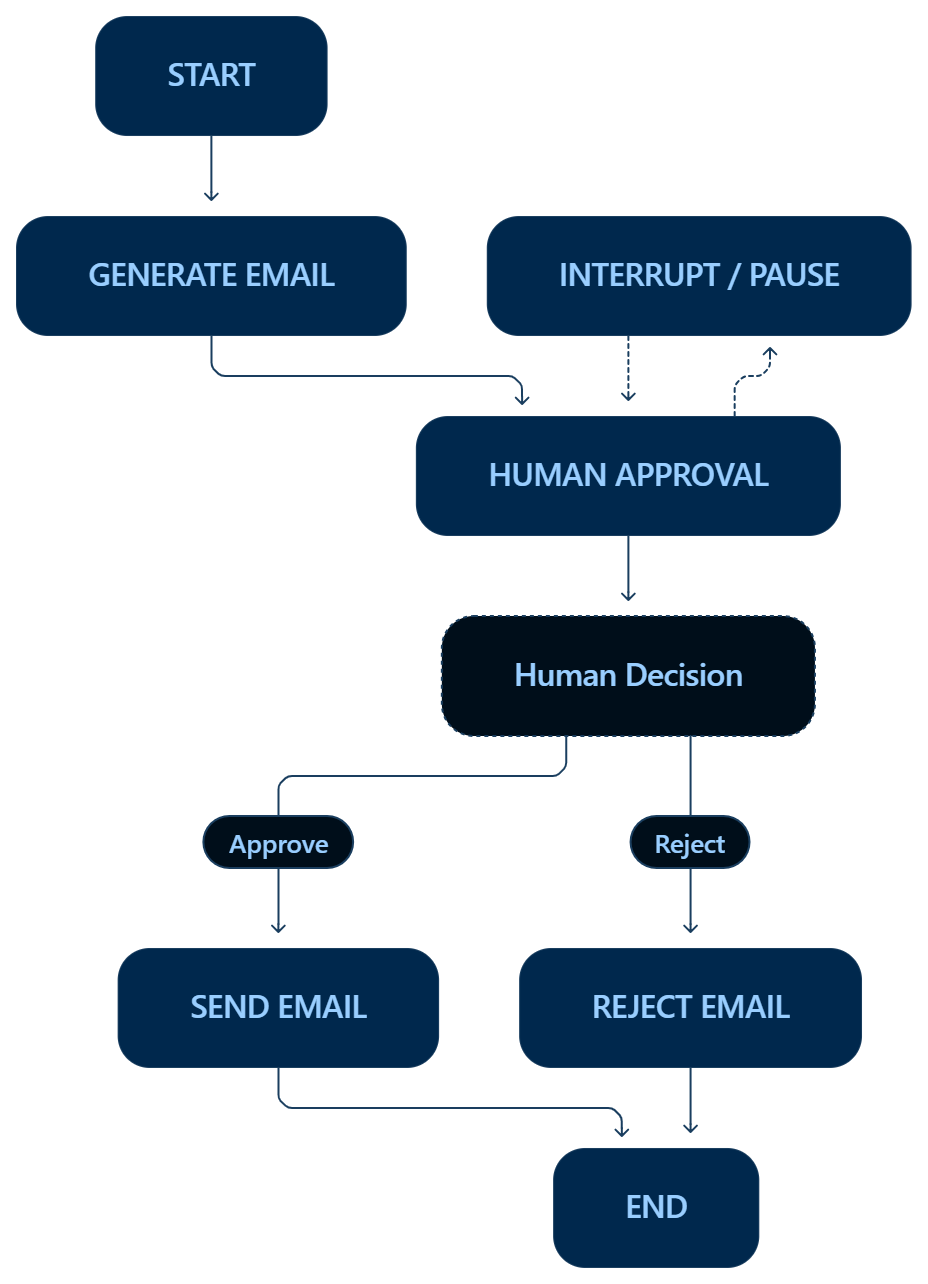

In [16]:
class EmailState(TypedDict):
    request: str
    draft_email: str
    human_decision: str
    final_status: str
print("EmailState created successfully!")

for field in EmailState.__annotations__:
    print("-", field)

EmailState created successfully!
- request
- draft_email
- human_decision
- final_status


In [17]:
def generate_email(state):
    print("\n[Generate] Creating email draft...")

    response = llm.invoke(
        f"""Create a professional email based on this request:

{state["request"]}

Keep the email clear, polite, and concise."""
    )

    return {
        "draft_email": response.content
    }


In [18]:
def human_approval(state):
    print("\n[Human Approval] Workflow paused.")
    print("\nEMAIL DRAFT:")
    print("-" * 50)
    print(state["draft_email"])
    print("-" * 50)

    decision = interrupt({
        "message": "Approve this email before sending?",
        "draft": state["draft_email"]
    })

    return {
        "human_decision": decision
    }


In [7]:
def approval_router(state):
    if state["human_decision"] == "approve":
        print("[Router] Human approved the email.")
        return "approved"

    print("[Router] Human rejected the email.")
    return "rejected"

In [19]:
def send_email(state):
    print("\n[Send Email] Simulated email sending...")
    
    return {
        "final_status": "Email sent successfully after human approval."
    }


In [20]:
def reject_email(state):
    print("\n[Reject] Email was rejected by human.")

    return {
        "final_status": "Email was rejected and not sent."
    }


In [22]:
graph_builder = StateGraph(EmailState)

graph_builder.add_node("generate", generate_email)
graph_builder.add_node("human_approval", human_approval)
graph_builder.add_node("send_email", send_email)
graph_builder.add_node("reject_email", reject_email)

graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", "human_approval")

graph_builder.add_conditional_edges(
    "human_approval",
    approval_router,
    {
        "approved": "send_email",
        "rejected": "reject_email"
    }
)

graph_builder.add_edge("send_email", END)
graph_builder.add_edge("reject_email", END)

memory = MemorySaver()

graph = graph_builder.compile(
    checkpointer=memory
)


In [24]:
initial_state = {
    "request": "Write an email to my manager requesting one day leave.",
    "draft_email": "",
    "human_decision": "",
    "final_status": ""
}

config = {
    "configurable": {
        "thread_id": "task4-demo-1"
    }
}

result = graph.invoke(
    initial_state,
    config=config
)

print(result)


[Generate] Creating email draft...


c:\Users\samir\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.



[Human Approval] Workflow paused.

EMAIL DRAFT:
--------------------------------------------------
[{'type': 'text', 'text': "Subject: Leave Request - [Your Name] - [Date of Leave]\n\nDear [Manager's Name],\n\nPlease accept this email as a request for one day of annual leave on [Date of Leave]. \n\nAhead of my absence, I will ensure that all my pending tasks are up to date and delegate any urgent matters to [Colleague's Name, optional]. I can also be reached by phone in case of an emergency.\n\nThank you for considering my request. \n\nBest regards,\n\n[Your Name]  \n[Your Title]", 'extras': {'signature': 'El4KXAERTTIPYspwZTOIzwegMO4oBwGQLIF20ctHzpzqMA+8QLG6hednKVBBBB7Fw2YRMCpd8agW5z1a8YmDJeg59fk6jBnRwW3vznj8ZE+I4KE70PuQA0FPRrEwoT2Q'}}]
--------------------------------------------------
{'request': 'Write an email to my manager requesting one day leave.', 'draft_email': [{'type': 'text', 'text': "Subject: Leave Request - [Your Name] - [Date of Leave]\n\nDear [Manager's Name],\n\nPleas

In [25]:
state = graph.get_state(config)

print("Current graph state:")
print(state.values)

Current graph state:
{'request': 'Write an email to my manager requesting one day leave.', 'draft_email': [{'type': 'text', 'text': "Subject: Leave Request - [Your Name] - [Date of Leave]\n\nDear [Manager's Name],\n\nPlease accept this email as a request for one day of annual leave on [Date of Leave]. \n\nAhead of my absence, I will ensure that all my pending tasks are up to date and delegate any urgent matters to [Colleague's Name, optional]. I can also be reached by phone in case of an emergency.\n\nThank you for considering my request. \n\nBest regards,\n\n[Your Name]  \n[Your Title]", 'extras': {'signature': 'El4KXAERTTIPYspwZTOIzwegMO4oBwGQLIF20ctHzpzqMA+8QLG6hednKVBBBB7Fw2YRMCpd8agW5z1a8YmDJeg59fk6jBnRwW3vznj8ZE+I4KE70PuQA0FPRrEwoT2Q'}}], 'human_decision': '', 'final_status': ''}


In [26]:
print("\nDRAFT EMAIL:")
print(state.values["draft_email"])


DRAFT EMAIL:
[{'type': 'text', 'text': "Subject: Leave Request - [Your Name] - [Date of Leave]\n\nDear [Manager's Name],\n\nPlease accept this email as a request for one day of annual leave on [Date of Leave]. \n\nAhead of my absence, I will ensure that all my pending tasks are up to date and delegate any urgent matters to [Colleague's Name, optional]. I can also be reached by phone in case of an emergency.\n\nThank you for considering my request. \n\nBest regards,\n\n[Your Name]  \n[Your Title]", 'extras': {'signature': 'El4KXAERTTIPYspwZTOIzwegMO4oBwGQLIF20ctHzpzqMA+8QLG6hednKVBBBB7Fw2YRMCpd8agW5z1a8YmDJeg59fk6jBnRwW3vznj8ZE+I4KE70PuQA0FPRrEwoT2Q'}}]


In [27]:
approval_result = graph.invoke(
    Command(resume="approve"),
    config=config
)

print("\nFINAL RESULT:")
print(approval_result)


[Human Approval] Workflow paused.

EMAIL DRAFT:
--------------------------------------------------
[{'type': 'text', 'text': "Subject: Leave Request - [Your Name] - [Date of Leave]\n\nDear [Manager's Name],\n\nPlease accept this email as a request for one day of annual leave on [Date of Leave]. \n\nAhead of my absence, I will ensure that all my pending tasks are up to date and delegate any urgent matters to [Colleague's Name, optional]. I can also be reached by phone in case of an emergency.\n\nThank you for considering my request. \n\nBest regards,\n\n[Your Name]  \n[Your Title]", 'extras': {'signature': 'El4KXAERTTIPYspwZTOIzwegMO4oBwGQLIF20ctHzpzqMA+8QLG6hednKVBBBB7Fw2YRMCpd8agW5z1a8YmDJeg59fk6jBnRwW3vznj8ZE+I4KE70PuQA0FPRrEwoT2Q'}}]
--------------------------------------------------
[Router] Human approved the email.

[Send Email] Simulated email sending...

FINAL RESULT:
{'request': 'Write an email to my manager requesting one day leave.', 'draft_email': [{'type': 'text', 'text':

In [28]:
config_reject = {
    "configurable": {
        "thread_id": "task4-demo-2"
    }
}

In [29]:
graph.invoke(
    {
        "request": "Write an email to my manager requesting one day leave.",
        "draft_email": "",
        "human_decision": "",
        "final_status": ""
    },
    config=config_reject
)


[Generate] Creating email draft...


c:\Users\samir\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(



[Human Approval] Workflow paused.

EMAIL DRAFT:
--------------------------------------------------
[{'type': 'text', 'text': "Subject: Leave Request - [Date] - [Your Name]\n\nDear [Manager's Name],\n\nPlease accept this email as a request for one day of annual leave on [Date]. \n\nI have ensured that my current tasks are up to date, and [Colleague's Name] has kindly agreed to cover any urgent matters that may arise while I am away. \n\nI will have limited access to my email in case of an absolute emergency. \n\nThank you for considering my request. \n\nBest regards,\n\n[Your Name]  \n[Your Title]", 'extras': {'signature': 'El4KXAERTTIPLPe9KYE/qtjSCqpL0erGZNxoEFflNUmJW26+C1SlnFvFG4ta9kYN3aeaIe7ObtFYnwrL5hFAp35IA4T2Ir1YXk03Dk+3cEFi198ttlJadhlOP3SQ81Q9'}}]
--------------------------------------------------


{'request': 'Write an email to my manager requesting one day leave.',
 'draft_email': [{'type': 'text',
   'text': "Subject: Leave Request - [Date] - [Your Name]\n\nDear [Manager's Name],\n\nPlease accept this email as a request for one day of annual leave on [Date]. \n\nI have ensured that my current tasks are up to date, and [Colleague's Name] has kindly agreed to cover any urgent matters that may arise while I am away. \n\nI will have limited access to my email in case of an absolute emergency. \n\nThank you for considering my request. \n\nBest regards,\n\n[Your Name]  \n[Your Title]",
   'extras': {'signature': 'El4KXAERTTIPLPe9KYE/qtjSCqpL0erGZNxoEFflNUmJW26+C1SlnFvFG4ta9kYN3aeaIe7ObtFYnwrL5hFAp35IA4T2Ir1YXk03Dk+3cEFi198ttlJadhlOP3SQ81Q9'}}],
 'human_decision': '',
 'final_status': '',
 '__interrupt__': [Interrupt(value={'message': 'Approve this email before sending?', 'draft': [{'type': 'text', 'text': "Subject: Leave Request - [Date] - [Your Name]\n\nDear [Manager's Name],\n\nPl

In [30]:
rejection_result = graph.invoke(
    Command(resume="reject"),
    config=config_reject
)

print("\nFINAL RESULT:")
print(rejection_result)


[Human Approval] Workflow paused.

EMAIL DRAFT:
--------------------------------------------------
[{'type': 'text', 'text': "Subject: Leave Request - [Date] - [Your Name]\n\nDear [Manager's Name],\n\nPlease accept this email as a request for one day of annual leave on [Date]. \n\nI have ensured that my current tasks are up to date, and [Colleague's Name] has kindly agreed to cover any urgent matters that may arise while I am away. \n\nI will have limited access to my email in case of an absolute emergency. \n\nThank you for considering my request. \n\nBest regards,\n\n[Your Name]  \n[Your Title]", 'extras': {'signature': 'El4KXAERTTIPLPe9KYE/qtjSCqpL0erGZNxoEFflNUmJW26+C1SlnFvFG4ta9kYN3aeaIe7ObtFYnwrL5hFAp35IA4T2Ir1YXk03Dk+3cEFi198ttlJadhlOP3SQ81Q9'}}]
--------------------------------------------------
[Router] Human rejected the email.

[Reject] Email was rejected by human.

FINAL RESULT:
{'request': 'Write an email to my manager requesting one day leave.', 'draft_email': [{'type': 

## Task 4 Explanation

Human-in-the-loop is useful when an agent is about to perform a risky, irreversible, expensive, or sensitive action. In this workflow, the graph pauses before sending an email and waits for human approval or rejection. Full autonomy is more appropriate for low-risk and reversible tasks where mistakes have limited consequences, while human approval should be required for actions such as financial transactions, external communications, destructive operations, or important business decisions.